# SIT720 11.1HD — Part 1 Reproduction
## Paper: *An efficient stacking-based ensemble technique for early heart attack prediction*

Reproduce the six classifiers and 5-fold stacking model reported in the paper, then compare the reproduced results with the published results.


## 1. Reproduction setup

- Data: 1025 rows, 13 predictors + `target`.
- Models: LR, DT, RF, XGB, NB, KNN, and 5-fold stacking.
- Metrics: Accuracy, Precision, Recall, F1, and AUC.
- Assumptions: 80/20 split, `random_state=42`, no stratification, `StandardScaler`, default model settings where unspecified, and Logistic Regression as the stacking meta-classifier.
- No imputation is applied because this CSV has no missing values.


## 2. Imports and environment

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)

try:
    import xgboost
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError("xgboost is required. Install it with: pip install xgboost") from e

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

Python: 3.12.4
pandas: 2.1.4
scikit-learn: 1.5.1
xgboost: 2.1.3


## 3. Load the dataset

In [2]:
DATA_PATH = Path("archive") / "heart.csv"
if not DATA_PATH.exists():
    DATA_PATH = Path("heart.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())


Dataset: archive\heart.csv
Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 4. Dataset audit

Check the dataset shape, missing values, class balance, duplicates, and feature ranges before modelling.


In [3]:
expected_columns = [
    'age','sex','cp','trestbps','chol','fbs','restecg','thalach',
    'exang','oldpeak','slope','ca','thal','target'
]

print("Columns match expected order:", list(df.columns) == expected_columns)
print("Total missing values:", int(df.isna().sum().sum()))
print("Class counts:", df['target'].value_counts().sort_index().to_dict())
print("Duplicate rows:", int(df.duplicated().sum()))
print("Unique rows:", len(df.drop_duplicates()))
print("Unique values of ca:", sorted(df['ca'].unique().tolist()))
print("Unique values of thal:", sorted(df['thal'].unique().tolist()))

assert df.shape == (1025, 14), "Unexpected dataset shape."
assert set(df['target'].unique()) == {0, 1}, "Target should be binary 0/1."

Columns match expected order: True
Total missing values: 0
Class counts: {0: 499, 1: 526}
Duplicate rows: 723
Unique rows: 302
Unique values of ca: [0, 1, 2, 3, 4]
Unique values of thal: [0, 1, 2, 3]


### Audit notes

- Shape and columns match the paper: 1025 × 14.
- No missing values are present.
- The file contains 723 duplicate rows.
- `ca=4` and `thal=0` appear although the paper reports narrower ranges.
- Keep the original data unchanged for Part 1 and analyse these issues separately.


## 5. Paper-reported results (Table 11)

In [4]:
paper_results = pd.DataFrame({
    "Model": ["LR", "DT", "RF", "XGB", "NB", "KNN", "Stacking"],
    "Paper Accuracy": [0.8439, 0.9268, 0.9268, 0.9073, 0.8439, 0.8585, 0.9853],
    "Paper Precision": [0.8196, 0.9702, 0.9130, 0.9174, 0.8250, 0.8648, 1.0000],
    "Paper Recall": [0.9090, 0.8909, 0.9545, 0.9090, 0.9000, 0.8727, 0.9727],
    "Paper F1": [0.8620, 0.9289, 0.9333, 0.9132, 0.8608, 0.8687, 0.9861],
    "Paper AUC": [0.9204, 0.9702, 0.9734, 0.9830, 0.9185, 0.9304, 0.9880],
})
display(paper_results)

,Model,Paper Accuracy,Paper Precision,Paper Recall,Paper F1,Paper AUC
0,LR,0.8439,0.8196,0.9090,0.8620,0.9204
1,DT,0.9268,0.9702,0.8909,0.9289,0.9702
2,RF,0.9268,0.9130,0.9545,0.9333,0.9734
3,XGB,0.9073,0.9174,0.9090,0.9132,0.9830
4,NB,0.8439,0.8250,0.9000,0.8608,0.9185
5,KNN,0.8585,0.8648,0.8727,0.8687,0.9304
6,Stacking,0.9853,1.0000,0.9727,0.9861,0.9880


## 6. Train/test split and preprocessing

- Use an 80/20 split, giving 205 test samples as in the paper's results.
- The paper does not report the random seed or stratification setting;
  `random_state=42` and no stratification are reproduction assumptions.
- Standard scaling is used to implement the paper's stated numeric scaling step.
- No imputation is applied because this CSV contains no missing values.
- All 13 predictors are retained, consistent with the paper's 14 attributes
  including the target.

In [5]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=None
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))
print("Test class counts:", y_test.value_counts().sort_index().to_dict())

Training size: 820
Testing size: 205
Test class counts: {0: 102, 1: 103}


## 7. Standalone models

Use the six classifiers named in the paper. Keep library defaults where the paper does not report hyperparameters, with fixed random states for reproducibility.


In [6]:
models = {
    "LR": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "DT": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RF": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGB": XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    "NB": GaussianNB(),
    "KNN": KNeighborsClassifier(),
}

models

{'LR': LogisticRegression(max_iter=2000, random_state=42),
 'DT': DecisionTreeClassifier(random_state=42),
 'RF': RandomForestClassifier(random_state=42),
 'XGB': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, random_state=42, ...),
 'NB': GaussianNB(),
 'KNN': KNeighborsClassifier()}

## 8. Evaluation helper

In [7]:
def evaluate_classifier(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(Xte)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(Xte)
    else:
        y_score = y_pred

    return {
        "Model": name,
        "Accuracy": accuracy_score(yte, y_pred),
        "Precision": precision_score(yte, y_pred, zero_division=0),
        "Recall": recall_score(yte, y_pred, zero_division=0),
        "F1": f1_score(yte, y_pred, zero_division=0),
        "AUC": roc_auc_score(yte, y_score),
        "Confusion Matrix": confusion_matrix(yte, y_pred),
        "Predictions": y_pred,
        "Scores": y_score,
        "Fitted Model": model,
    }

## 9. Train and evaluate all six standalone classifiers

In [8]:
standalone_evaluations = []

for name, model in models.items():
    result = evaluate_classifier(
        name, model,
        X_train_scaled, X_test_scaled,
        y_train, y_test
    )
    standalone_evaluations.append(result)

standalone_table = pd.DataFrame([
    {k: v for k, v in r.items() if k in ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]}
    for r in standalone_evaluations
])

display(standalone_table.round(4))

,Model,Accuracy,Precision,Recall,F1,AUC
0,LR,0.7951,0.7563,0.8738,0.8108,0.8787
1,DT,0.9854,1.0000,0.9709,0.9852,0.9854
2,RF,0.9854,1.0000,0.9709,0.9852,1.0000
3,XGB,0.9854,1.0000,0.9709,0.9852,0.9894
4,NB,0.8000,0.7541,0.8932,0.8178,0.8706
5,KNN,0.8341,0.8000,0.8932,0.8440,0.9486


<a id="clean-10"></a>
## 10. 5-fold stacking ensemble

The six paper classifiers are combined using 5-fold stacking.
Logistic Regression is used as the meta-classifier because the paper does not
specify the final estimator.

For Part 1, the scaler was fitted once using the full training set before the stacking model performed its internal 5-fold cross-validation. This means the validation fold had already contributed to the scaling statistics, so preprocessing was not completely separated between folds. In Part 2, pipelines were used so that scaling was fitted only on the training portion of each fold.

The code attempts to do the following:

First split the 820 training samples into 5 folds of 164 samples each.
For each model, take DT for example:
1. Define a NEW DT model and train it on 4 folds (656 samples).
2. Predict on the remaining fold (164 samples). These are the "out-of
-fold" predictions for this fold. Store the predicted probabilities.
3. Repeat this for all 5 folds.

After 5 folds on all 6 models, for each sample in the training set,
there are 6 predictions, stored as probabilities. The stacking
classifier uses these 6 predictions as features to train.

Then all 6 base models are trained on the entire training set 
(4 folds of 656 + 1 fold of 164 = 820 samples) and used to predict
on the test set. The stacking classifier uses these 6 predictions 
as features to predict on the test set.
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html

In [9]:
stack_estimators = [
    ("lr", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE)),
    ("xgb", XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')),
    ("nb", GaussianNB()),
    ("knn", KNeighborsClassifier()),
]

stacking_model = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1
)

stack_result = evaluate_classifier(
    "Stacking", stacking_model,
    X_train_scaled, X_test_scaled,
    y_train, y_test
)

stack_table = pd.DataFrame([{k: v for k, v in stack_result.items()
                             if k in ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]}])
display(stack_table.round(4))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Stacking,0.9854,1.0,0.9709,0.9852,1.0


## 11. Combine reproduction results and compare against the paper

In [10]:
# Compare the metrics from Table 11 in the paper with the reproduced
# metrics. Comparison includes results from 6 standalone models and 
# the stacking model. 

all_eval = standalone_evaluations + [stack_result]
reproduced = pd.DataFrame([
    {k: v for k, v in r.items() if k in ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]}
    for r in all_eval
])

comparison = paper_results.merge(reproduced, on="Model", how="left")
comparison["Accuracy Difference"] = comparison["Accuracy"] - comparison["Paper Accuracy"]
comparison["Precision Difference"] = comparison["Precision"] - comparison["Paper Precision"]
comparison["Recall Difference"] = comparison["Recall"] - comparison["Paper Recall"]
comparison["F1 Difference"] = comparison["F1"] - comparison["Paper F1"]
comparison["AUC Difference"] = comparison["AUC"] - comparison["Paper AUC"]

cols = [
    "Model", "Paper Accuracy", "Accuracy", "Accuracy Difference",
    "Paper Precision", "Precision", "Paper Recall", "Recall",
    "Paper F1", "F1", "Paper AUC", "AUC"
]
display(comparison[cols].round(4))

# Save a report-ready CSV
comparison[cols].to_csv("results_part1.csv", index=False)
print("Saved: results_part1.csv")

,Model,Paper Accuracy,Accuracy,Accuracy Difference,Paper Precision,Precision,Paper Recall,Recall,Paper F1,F1,Paper AUC,AUC
0,LR,0.8439,0.7951,-0.0488,0.8196,0.7563,0.9090,0.8738,0.8620,0.8108,0.9204,0.8787
1,DT,0.9268,0.9854,0.0586,0.9702,1.0000,0.8909,0.9709,0.9289,0.9852,0.9702,0.9854
2,RF,0.9268,0.9854,0.0586,0.9130,1.0000,0.9545,0.9709,0.9333,0.9852,0.9734,1.0000
3,XGB,0.9073,0.9854,0.0781,0.9174,1.0000,0.9090,0.9709,0.9132,0.9852,0.9830,0.9894
4,NB,0.8439,0.8000,-0.0439,0.8250,0.7541,0.9000,0.8932,0.8608,0.8178,0.9185,0.8706
5,KNN,0.8585,0.8341,-0.0244,0.8648,0.8000,0.8727,0.8932,0.8687,0.8440,0.9304,0.9486
6,Stacking,0.9853,0.9854,0.0001,1.0000,1.0000,0.9727,0.9709,0.9861,0.9852,0.9880,1.0000


Saved: results_part1.csv


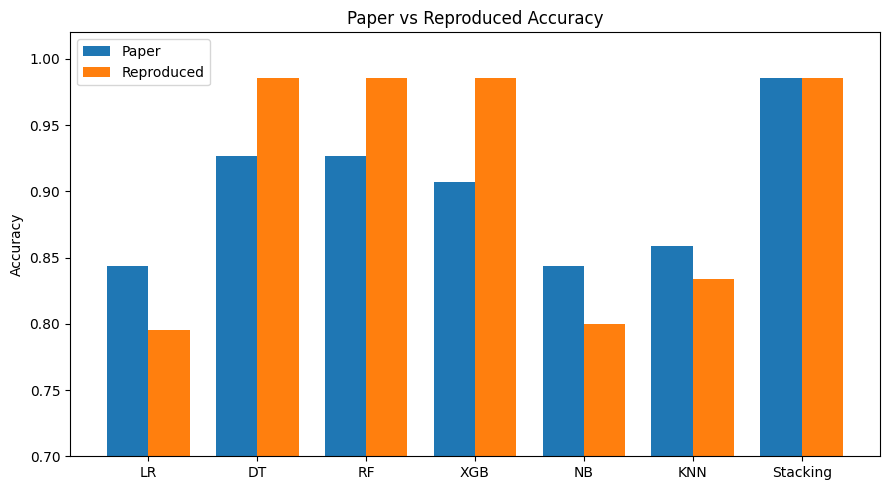

In [11]:
# Report Figure: paper vs reproduced accuracy
plot_df = comparison[
    ["Model", "Paper Accuracy", "Accuracy"]
].copy()

x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    x - width / 2,
    plot_df["Paper Accuracy"],
    width,
    label="Paper"
)

ax.bar(
    x + width / 2,
    plot_df["Accuracy"],
    width,
    label="Reproduced"
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Model"])
ax.set_ylabel("Accuracy")
ax.set_ylim(0.70, 1.02)
ax.set_title("Paper vs Reproduced Accuracy")
ax.legend()

plt.tight_layout()
plt.show()

## 12. Confusion matrices

Inspect false positives and false negatives for each model, especially missed disease cases.


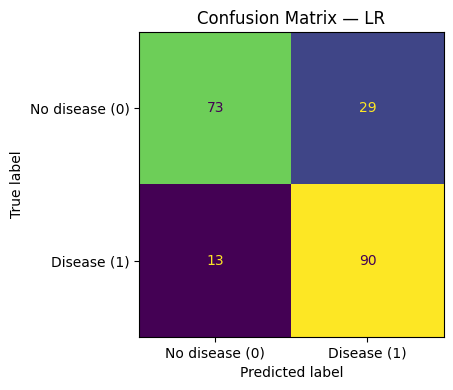

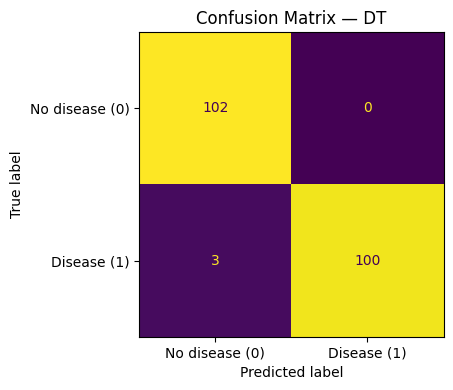

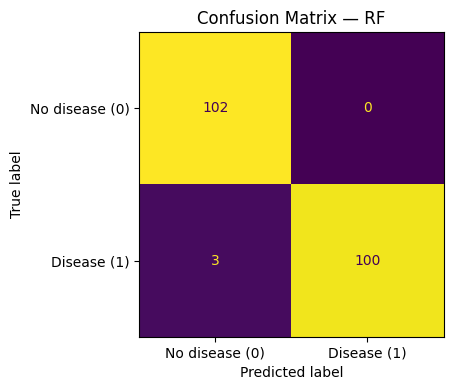

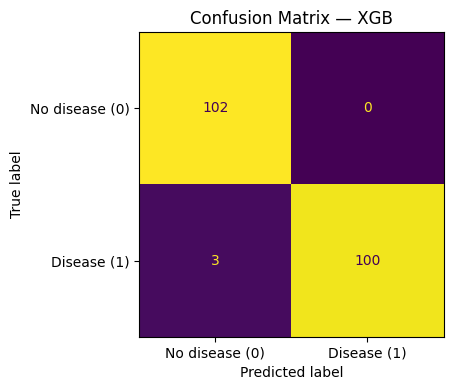

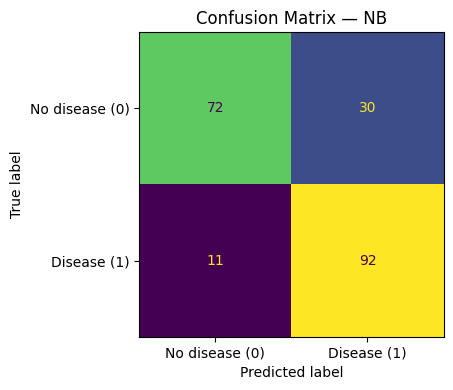

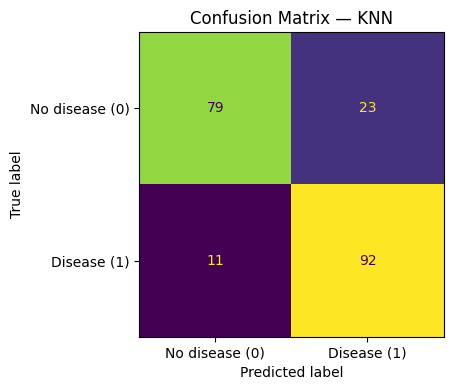

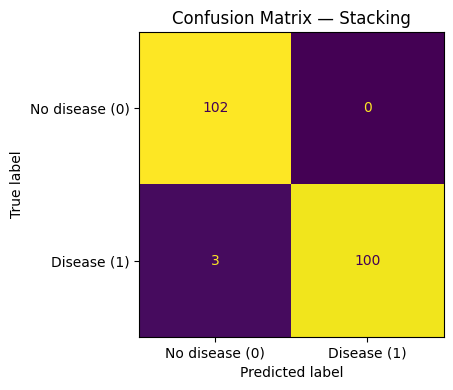

In [12]:
for r in all_eval:
    fig, ax = plt.subplots(figsize=(4.5, 4.0))
    ConfusionMatrixDisplay(
        confusion_matrix=r["Confusion Matrix"],
        display_labels=["No disease (0)", "Disease (1)"]
    ).plot(ax=ax, values_format='d', colorbar=False)
    ax.set_title(f"Confusion Matrix — {r['Model']}")
    plt.tight_layout()
    plt.show()

## 13. ROC curves

Compute ROC-AUC from model scores/probabilities and compare discrimination across models.


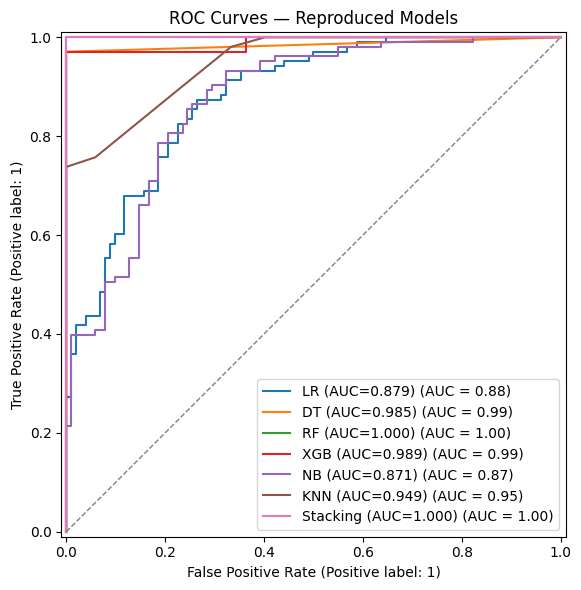

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
for r in all_eval:
    RocCurveDisplay.from_predictions(
        y_test,
        r["Scores"],
        name=f"{r['Model']} (AUC={r['AUC']:.3f})",
        ax=ax
    )
ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
ax.set_title("ROC Curves — Reproduced Models")
plt.tight_layout()
plt.show()

## 14. Feature importance

Use Random Forest feature importance for comparison with the paper. No features are removed in Part 1.


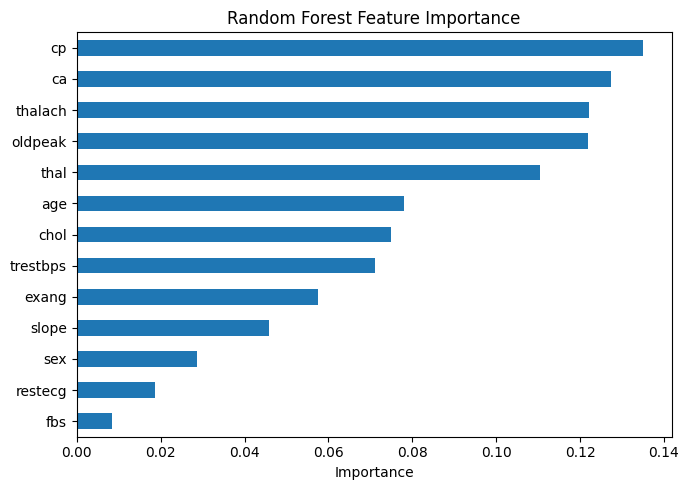

,importance
cp,0.1351
ca,0.1273
thalach,0.1222
oldpeak,0.1219
thal,0.1105
age,0.0779
chol,0.0748
trestbps,0.0712
exang,0.0576
slope,0.0458


In [14]:
rf_fitted = next(r["Fitted Model"] for r in standalone_evaluations if r["Model"] == "RF")
importance = pd.Series(rf_fitted.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
importance.plot(kind='barh', ax=ax)
ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

display(importance.sort_values(ascending=False).to_frame("importance").round(4))

## 15. Duplicate-overlap diagnostic

Check whether test rows have exact copies in the training set. High overlap can make test performance overly optimistic.


In [15]:
# Predictor-only exact matches
train_predictor_rows = set(map(tuple, X_train.to_numpy()))
test_has_train_duplicate = X_test.apply(lambda row: tuple(row.to_numpy()) in train_predictor_rows, axis=1)

# Exact full-row matches including target, for audit only
train_full_rows = set(map(tuple, pd.concat([X_train, y_train], axis=1).to_numpy()))
test_full = pd.concat([X_test, y_test], axis=1)
test_has_full_duplicate = test_full.apply(lambda row: tuple(row.to_numpy()) in train_full_rows, axis=1)

print(f"Test rows with identical predictor row in training: {test_has_train_duplicate.sum()} / {len(X_test)} "
      f"({test_has_train_duplicate.mean():.1%})")
print(f"Test rows with identical full row (including target) in training: {test_has_full_duplicate.sum()} / {len(X_test)} "
      f"({test_has_full_duplicate.mean():.1%})")

Test rows with identical predictor row in training: 199 / 205 (97.1%)
Test rows with identical full row (including target) in training: 199 / 205 (97.1%)


## 16. Additional diagnostic checks

### 16.1 Paper metric consistency

The selected paper reports the final stacking results in several places:

- Figure 5 on page 21 shows the confusion matrix for the proposed stacking ensemble:
  - True Negative (TN) = 95
  - False Positive (FP) = 0
  - False Negative (FN) = 3
  - True Positive (TP) = 107

Because all classification metrics can be derived directly from the confusion matrix, the next cell recalculates them from Figure 5 and compares the implied values with the values reported in Tables 11 on page 18 and 12 on page 21.

In [16]:
# Check metrics implied by the paper's stacking confusion matrix (Fig. 5)
paper_tn, paper_fp, paper_fn, paper_tp = 95, 0, 3, 107

paper_cm_accuracy = (
    paper_tp + paper_tn
) / (
    paper_tp + paper_tn + paper_fp + paper_fn
)

paper_cm_recall = paper_tp / (paper_tp + paper_fn)
paper_cm_specificity = paper_tn / (paper_tn + paper_fp)
paper_cm_precision = paper_tp / (paper_tp + paper_fp)

paper_cm_f1 = (
    2 * paper_cm_precision * paper_cm_recall
    / (paper_cm_precision + paper_cm_recall)
)

paper_cm_mcc = (
    paper_tp * paper_tn - paper_fp * paper_fn
) / np.sqrt(
    (paper_tp + paper_fp)
    * (paper_tp + paper_fn)
    * (paper_tn + paper_fp)
    * (paper_tn + paper_fn)
)

pd.DataFrame({
    "Metric": [
        "Accuracy", "Recall/Sensitivity",
        "Specificity", "Precision", "F1", "MCC"
    ],
    "Derived from Fig. 5": [
        paper_cm_accuracy,
        paper_cm_recall,
        paper_cm_specificity,
        paper_cm_precision,
        paper_cm_f1,
        paper_cm_mcc
    ]
}).round(4)

,Metric,Derived from Fig. 5
0,Accuracy,0.9854
1,Recall/Sensitivity,0.9727
2,Specificity,1.0000
3,Precision,1.0000
4,F1,0.9862
5,MCC,0.9711


- Table 11 on page 18 reports the main classifier metrics. For the proposed stacking model, it reports:
  - Accuracy = 0.9853
  - F1 = 0.9861
  - Recall = 0.9727
  - Precision = 1.0000
  - AUC = 0.9880

- Table 12 on page 21 separately reports:
  - Sensitivity = 0.9853
  - Specificity = 0.9861
  - Precision = 1.0000
  - Accuracy = 0.9853
  - F1 = 0.9861
  - AUC = 0.9880
  - MCC = 1.0000


### 16.2 Random-seed sensitivity of the Part 1 train/test split

Part 1 uses an 80/20 random train/test split with `random_state=42`.  
However, the selected paper does not report the random seed used for its experiment.

A single random split can sometimes produce unusually high or low results, especially on a small dataset. Therefore, this diagnostic repeats the same 80/20 experiment using ten different random seeds:

`0, 1, 2, 3, 4, 5, 10, 20, 42, 100`

Two representative classifiers are checked:

- Logistic Regression (LR), because its Part 1 accuracy was much lower than the tree-based models; and
- Random Forest (RF), because it achieved almost perfect accuracy in the reproduction.

The  experiment checks whether the near-perfect Random Forest result occurs only for `random_state=42` or remains present across many different random train/test splits.

In [17]:
seed_rows = []
for seed in [0, 1, 2, 3, 4, 5, 10, 20, 42, 100]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, random_state=seed, stratify=None)
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)

    for name, model in {
        "LR": LogisticRegression(max_iter=2000, random_state=seed),
        "RF": RandomForestClassifier(random_state=seed)
    }.items():
        model.fit(Xtr_s, ytr)
        pred = model.predict(Xte_s)
        seed_rows.append({"Seed": seed, "Model": name, "Accuracy": accuracy_score(yte, pred)})

seed_df = pd.DataFrame(seed_rows)
display(seed_df.pivot(index="Seed", columns="Model", values="Accuracy").round(4))
print("Accuracy mean/std by model:")
display(seed_df.groupby("Model")["Accuracy"].agg(["mean", "std", "min", "max"]).round(4))

Model,LR,RF
Seed,,
0,0.8634,1.0000
1,0.8098,1.0000
2,0.8439,1.0000
3,0.8244,1.0000
4,0.8146,1.0000
5,0.8488,1.0000
10,0.8585,1.0000
20,0.7951,1.0000
42,0.7951,0.9854


Accuracy mean/std by model:


,mean,std,min,max
Model,,,,
LR,0.8317,0.0272,0.7951,0.8634
RF,0.9985,0.0046,0.9854,1.0000


## 17. Key observations

- The paper does not fully specify the random seed, hyperparameters, or stacking meta-classifier.
- Some reported XGB and stacking accuracies are inconsistent across the paper; Table 11 is used as the main reference.
- The dataset contains many duplicates, and most test rows have an identical training copy under the current split.
- `ca` and `thal` contain values outside the ranges listed in the paper.
- These issues may contribute to the result differences and motivate stricter validation in Part 2.
- The paper also contains metric inconsistencies. Metrics derived from the
  stacking confusion matrix do not match several values reported in Table 12.

# Part 2 — Leakage-aware ML solution

Address duplicate overlap with stricter validation, feature selection, tuning, and a different ensemble strategy.

## 18. Proposed design

- Remove exact duplicate records before evaluation.
- Use stratified validation on the duplicate-free dataset.
- Apply MI feature selection with categorical variables treated as discrete.
- Tune LR, RF, XGB, and KNN using AUC.
- Combine them using soft voting.
- Use LR, KNN, RF, and XGB to provide complementary linear, distance-based,
  bagging, and boosting learners.
- Compare the proposed method with duplicate-free stacking.

In [18]:
from functools import partial

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import VotingClassifier

## 19. Build a duplicate-free dataset

In [19]:
# Extract feature columns (all except target)
feature_cols = [c for c in df.columns if c != "target"]

# Check whether rows with the same input features have different target labels.
label_counts = df.groupby(feature_cols, dropna=False)["target"].nunique()
conflicting_patterns = int((label_counts > 1).sum())

clean_df = df.drop_duplicates().reset_index(drop=True)

print("Original rows:", len(df))
print("Unique full rows:", len(clean_df))
print("Removed exact duplicates:", len(df) - len(clean_df))
print("Predictor patterns with conflicting labels:", conflicting_patterns)
print("Clean class counts:", clean_df["target"].value_counts().sort_index().to_dict())

Original rows: 1025
Unique full rows: 302
Removed exact duplicates: 723
Predictor patterns with conflicting labels: 0
Clean class counts: {0: 138, 1: 164}


## 20. Duplicate-free baseline

Evaluate the same models on the duplicate-free dataset to measure the effect of duplicate records on model performance.

In [20]:
X_clean = clean_df.drop(columns="target")
y_clean = clean_df["target"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_clean
)

print("Clean training size:", len(Xc_train))
print("Clean testing size:", len(Xc_test))
print("Clean test class counts:", yc_test.value_counts().sort_index().to_dict())

Clean training size: 241
Clean testing size: 61
Clean test class counts: {0: 28, 1: 33}


In [21]:
clean_models = {
    "LR": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "DT": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RF": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGB": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        verbosity=0
    ),
    "NB": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GaussianNB())
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ]),
}

clean_baseline_eval = []
for name, model in clean_models.items():
    clean_baseline_eval.append(
        evaluate_classifier(
            name, model,
            Xc_train, Xc_test,
            yc_train, yc_test
        )
    )

clean_baseline_table = pd.DataFrame([
    {k: v for k, v in r.items()
     if k in ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]}
    for r in clean_baseline_eval
])

display(clean_baseline_table.round(4))

,Model,Accuracy,Precision,Recall,F1,AUC
0,LR,0.8033,0.8000,0.8485,0.8235,0.8712
1,DT,0.8033,0.8182,0.8182,0.8182,0.8019
2,RF,0.7541,0.7647,0.7879,0.7761,0.8615
3,XGB,0.7213,0.7353,0.7576,0.7463,0.8323
4,NB,0.7869,0.8333,0.7576,0.7937,0.8842
5,KNN,0.7869,0.7778,0.8485,0.8116,0.8377


In [22]:
# Same six-model stacking idea, now evaluated on duplicate-free data
clean_stack_estimators = [
    ("lr", Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ])),
    ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE)),
    ("xgb", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        verbosity=0
    )),
    ("nb", Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GaussianNB())
    ])),
    ("knn", Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ])),
]

clean_stacking = StackingClassifier(
    estimators=clean_stack_estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1
)

clean_stack_result = evaluate_classifier(
    "Clean Stacking",
    clean_stacking,
    Xc_train, Xc_test,
    yc_train, yc_test
)

display(pd.DataFrame([{
    k: v for k, v in clean_stack_result.items()
    if k in ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
}]).round(4))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Clean Stacking,0.7541,0.7647,0.7879,0.7761,0.8669


## 21. Model tuning

### 21.1 Cross-validation setup

Use 5-fold stratified cross-validation during model tuning.
Use stratification and the same random state.

In [23]:
# Cross-validation used by GridSearchCV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

### 21.2 Mutual Information feature selection

Mutual Information (MI) measures how much information a feature provides about the target.

For a feature \(X\) and target \(Y\), Mutual Information is:

$$
I(X;Y) = \sum_{x,y} p(x,y)
\log\left(\frac{p(x,y)}{p(x)p(y)}\right)
$$

where:

- \(p(x,y)\): probability that \(X=x\) and \(Y=y\) occur together
- \(p(x)\): probability of \(X=x\)
- \(p(y)\): probability of \(Y=y\)

If \(X\) and \(Y\) are independent, then:

$$
p(x,y) = p(x)p(y)
$$

so the MI score is close to 0.

A higher MI score means the feature provides more information about the target.

Scikit-learn's `mutual_info_classif` handles them differently:

- Binary and multi-category features are both treated as discrete, MI is calculated using the formula above from the observed feature-target frequencies.
- For continuous features, scikit-learn uses a k-nearest-neighbour-based estimator to estimate MI with the discrete target. Find how the MI is calculated here: https://github.com/scikit-learn/scikit-learn/blob/main/sklearn/feature_selection/_mutual_info.py

In [24]:
# Categorical features
discrete_cols = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

# Continuous numerical features
continuous_cols = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]

# Use a boolean mask to indicate which features are discrete vs continuous.
# True = discrete feature, False = continuous feature
discrete_mask = np.array([
    col in discrete_cols
    for col in X_clean.columns
])

# Mutual Information scoring function used by SelectKBest. MI will 
# be computed between the target and each feature.
mi_score = partial(
    mutual_info_classif,
    discrete_features=discrete_mask,
    random_state=RANDOM_STATE
)

print("Discrete features:", discrete_cols)
print("Continuous features:", continuous_cols)

Discrete features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Continuous features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


### 21.3 Define model search spaces

Four models are tuned for the proposed ensemble:

- LR: linear model
- RF: bagging/tree-based model
- XGB: boosting model
- KNN: distance-based model

For each model, GridSearchCV will test different hyperparameters together with
three feature-selection options: 8 features, 10 features, or all features.

In [25]:
search_spaces = {

    "LR": (
        Pipeline([
            ("select", SelectKBest(score_func=mi_score)),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            ))
        ]),
        {
            "select__k": [8, 10, "all"],
            "clf__C": [0.1, 1.0, 10.0],
        }
    ),

    "RF": (
        Pipeline([
            ("select", SelectKBest(score_func=mi_score)),
            ("clf", RandomForestClassifier(
                random_state=RANDOM_STATE
            ))
        ]),
        {
            "select__k": [8, 10, "all"],
            "clf__n_estimators": [200, 500],
            "clf__max_depth": [None, 5, 10],
            "clf__min_samples_leaf": [1, 2],
        }
    ),

    "XGB": (
        Pipeline([
            ("select", SelectKBest(score_func=mi_score)),
            ("clf", XGBClassifier(
                random_state=RANDOM_STATE,
                eval_metric="logloss",
                verbosity=0,
                n_jobs=1
            ))
        ]),
        {
            "select__k": [8, 10, "all"],
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [2, 3],
            "clf__learning_rate": [0.03, 0.10],
            "clf__subsample": [0.8, 1.0],
        }
    ),

    "KNN": (
        Pipeline([
            ("select", SelectKBest(score_func=mi_score)),
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        {
            "select__k": [8, 10, "all"],
            "clf__n_neighbors": [3, 5, 7, 9],
            "clf__weights": ["uniform", "distance"],
        }
    ),
}

### 21.4 Hyperparameter tuning with GridSearchCV

For one hyperparameter combination:

1. The training set is divided into 5 folds.
2. The model is trained on 4 folds and validated on the remaining fold.
3. This is repeated 5 times so that each fold is used once for validation.
4. The ROC-AUC scores from the 5 validation folds are averaged.

The same process is repeated for every hyperparameter combination. The combination with the highest mean validation ROC-AUC is selected as the best configuration. 

The separate test set is not used during feature selection or hyperparameter tuning.

In [26]:
searches = {}
tuning_rows = []

for name, (pipeline, params) in search_spaces.items():

    print(f"Tuning {name}...")

    # Define the search strategy
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,

        # refit=True means that after the best hyperparameters are found, 
        # the model will be refit on the entire training set using those 
        # best hyperparameters.
        refit=True
    )

    # Perform the grid search on the training set 
    search.fit(Xc_train, yc_train)

    # Keep the fitted search because Section 22 uses its best estimator
    searches[name] = search

    tuning_rows.append({
        "Model": name,
        "Best CV AUC": search.best_score_,
        "Best parameters": search.best_params_
    })

Tuning LR...
Tuning RF...
Tuning XGB...
Tuning KNN...


### 21.5 Best tuning results

The table below shows the best cross-validation AUC and the selected
hyperparameters for each model.

These tuned models will be used to build the Soft Voting ensemble in the next section.

In [27]:
tuning_table = pd.DataFrame(tuning_rows)
display(tuning_table)

,Model,Best CV AUC,Best parameters
0,LR,0.915592,"{'clf__C': 0.1, 'select__k': 'all'}"
1,RF,0.913520,"{'clf__max_depth': None, 'clf__min_samples_lea..."
2,XGB,0.910101,"{'clf__learning_rate': 0.03, 'clf__max_depth':..."
3,KNN,0.910839,"{'clf__n_neighbors': 9, 'clf__weights': 'unifo..."


## 22. Proposed ensemble

The proposed model combines four classifiers: Logistic Regression, Random Forest, XGBoost, and KNN.

In the previous section, `GridSearchCV` was used to find the best set of hyperparameters for each classifier, including the number of features selected by Mutual Information.

The four tuned classifiers are then combined using soft voting, which averages the predicted probabilities from the four models and uses the combined probability to make the final prediction.

Unlike stacking, this approach does not train an additional meta-classifier. It provides a simpler ensemble method to compare with clean stacking on the duplicate-free dataset.

In [28]:
# Use each classifier with its best hyperparameters found by GridSearchCV
proposed_model = VotingClassifier(
    estimators=[
        ("lr", clone(searches["LR"].best_estimator_)),
        ("rf", clone(searches["RF"].best_estimator_)),
        ("xgb", clone(searches["XGB"].best_estimator_)),
        ("knn", clone(searches["KNN"].best_estimator_)),
    ],
    voting="soft", # Average predicted probabilities from all four models
    n_jobs=-1
)

# Evaluate the proposed ensemble on the duplicate-free holdout set
proposed_result = evaluate_classifier(
    "Proposed Soft Voting",
    proposed_model,
    Xc_train, Xc_test,
    yc_train, yc_test
)

proposed_table = pd.DataFrame([{
    k: v for k, v in proposed_result.items()
    if k in ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
}])

display(proposed_table.round(4))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Proposed Soft Voting,0.7869,0.7941,0.8182,0.806,0.8777


## 23. Fair comparison on the same duplicate-free test set

Clean Stacking and Proposed Soft Voting are evaluated on the same duplicate-free training and test sets.

A second table includes the paper's reported stacking result and the Part 1 reproduced stacking result. They use the original duplicate-overlapping dataset.

In [29]:
# Keep only the main evaluation metrics for the two Part 2 ensembles
clean_stack_row = {
    k: v for k, v in clean_stack_result.items()
    if k in ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
}
proposed_row = {
    k: v for k, v in proposed_result.items()
    if k in ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
}

# Fair comparison: both models use the same duplicate-free test set
fair_comparison = pd.DataFrame([clean_stack_row, proposed_row])
display(fair_comparison.round(4))

# Add Part 1 and paper results
part1_stack = reproduced.loc[
    reproduced["Model"] == "Stacking",
    ["Accuracy", "Precision", "Recall", "F1", "AUC"]
].iloc[0]

context_comparison = pd.DataFrame([
    {
        "Setting": "Paper reported stacking",
        "Accuracy": float(paper_results.loc[paper_results["Model"] == "Stacking", "Paper Accuracy"].iloc[0]),
        "Precision": float(paper_results.loc[paper_results["Model"] == "Stacking", "Paper Precision"].iloc[0]),
        "Recall": float(paper_results.loc[paper_results["Model"] == "Stacking", "Paper Recall"].iloc[0]),
        "F1": float(paper_results.loc[paper_results["Model"] == "Stacking", "Paper F1"].iloc[0]),
        "AUC": float(paper_results.loc[paper_results["Model"] == "Stacking", "Paper AUC"].iloc[0]),
    },
    {
        "Setting": "Part 1 reproduced stacking",
        **part1_stack.to_dict()
    },
    {
        "Setting": "Part 2 clean stacking",
        **{k: clean_stack_result[k] for k in ["Accuracy", "Precision", "Recall", "F1", "AUC"]}
    },
    {
        "Setting": "Part 2 proposed soft voting",
        **{k: proposed_result[k] for k in ["Accuracy", "Precision", "Recall", "F1", "AUC"]}
    },
])

display(context_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Clean Stacking,0.7541,0.7647,0.7879,0.7761,0.8669
1,Proposed Soft Voting,0.7869,0.7941,0.8182,0.8060,0.8777


,Setting,Accuracy,Precision,Recall,F1,AUC
0,Paper reported stacking,0.9853,1.0000,0.9727,0.9861,0.9880
1,Part 1 reproduced stacking,0.9854,1.0000,0.9709,0.9852,1.0000
2,Part 2 clean stacking,0.7541,0.7647,0.7879,0.7761,0.8669
3,Part 2 proposed soft voting,0.7869,0.7941,0.8182,0.8060,0.8777


## 24. Confusion matrices and ROC curves

The two Part 2 ensemble models are further compared using confusion matrices and ROC curves on the same duplicate-free test set.

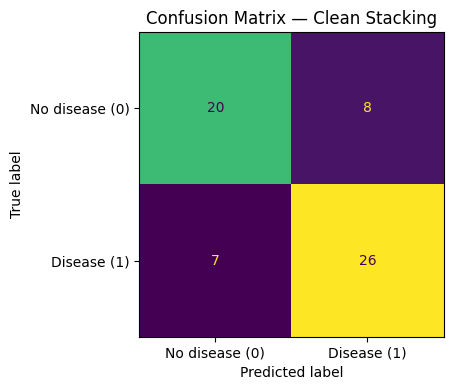

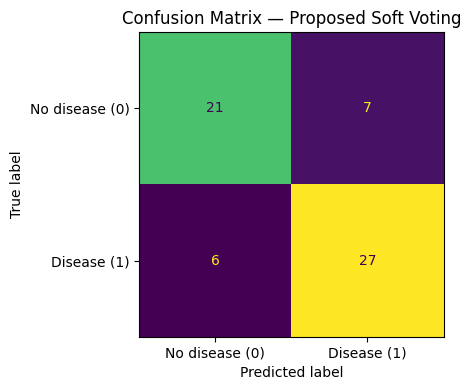

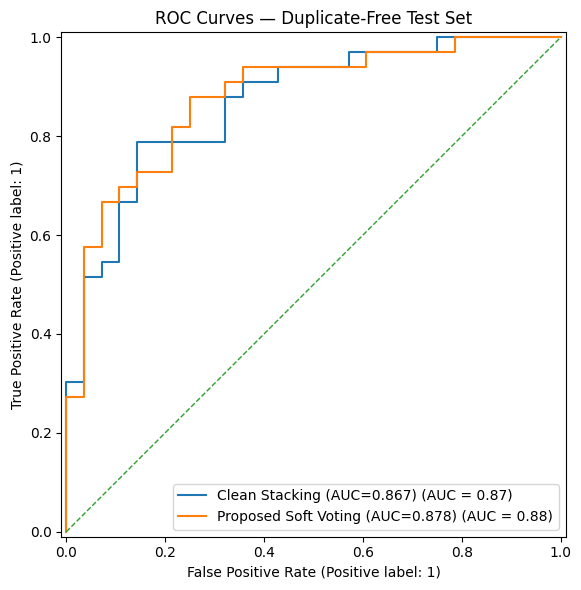

In [30]:
# Confusion matrix for each Part 2 ensemble
for r in [clean_stack_result, proposed_result]:
    fig, ax = plt.subplots(figsize=(4.5, 4.0))

    ConfusionMatrixDisplay(
        confusion_matrix=r["Confusion Matrix"],
        display_labels=["No disease (0)", "Disease (1)"]
    ).plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )

    ax.set_title(f"Confusion Matrix — {r['Model']}")
    plt.tight_layout()
    plt.show()


# Compare ROC curves on the same duplicate-free test set
fig, ax = plt.subplots(figsize=(7, 6))

for r in [clean_stack_result, proposed_result]:
    RocCurveDisplay.from_predictions(
        yc_test,
        r["Scores"],
        name=f"{r['Model']} (AUC={r['AUC']:.3f})",
        ax=ax
    )

# Diagonal line represents random classification
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

ax.set_title("ROC Curves — Duplicate-Free Test Set")
plt.tight_layout()
plt.show()

In [31]:
# Save Part 2 results
clean_baseline_table.to_csv("results_part2_clean_baselines.csv", index=False)
fair_comparison.to_csv("results_part2_fair_comparison.csv", index=False)
context_comparison.to_csv("results_part2_context_comparison.csv", index=False)

print("Saved Part 2 result tables.")

Saved Part 2 result tables.


## 25. Initial Part 2 finding

The first Part 2 comparison uses one duplicate-free 80/20 train-test split.

On this split, the proposed soft-voting model performs slightly better than clean stacking. However, the test set contains only 61 samples, so the result may depend on this particular split.

## 26. Robustness validation

The duplicate-free dataset contains 302 rows. Instead of relying on one 80/20 split, the following nested cross-validation procedure is used. 

In [32]:
from sklearn.model_selection import RepeatedStratifiedKFold

# Create a clean-stacking model
def make_clean_stacking():
    estimators = [
        # Scale features before Logistic Regression
        ("lr", Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            ))
        ])),

        ("dt", DecisionTreeClassifier(
            random_state=RANDOM_STATE
        )),

        ("rf", RandomForestClassifier(
            random_state=RANDOM_STATE
        )),

        ("xgb", XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            verbosity=0,
            n_jobs=1
        )),

        # Scale features before Naive Bayes and KNN
        ("nb", Pipeline([
            ("scaler", StandardScaler()),
            ("clf", GaussianNB())
        ])),

        ("knn", Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ])),
    ]

    # Combine the six base models using Logistic Regression as the meta-classifier
    return StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ),
        cv=5,
        n_jobs=-1
    )

## 27. Repeated nested cross-validation

In [33]:
from IPython.display import display, Markdown

display(Markdown("[See Clean Stacking explanation](#10)"))

[See Clean Stacking explanation](#10)

In [34]:
from IPython.display import display, Markdown

display(Markdown("[See Clean Stacking explanation](#clean-stacking)"))
# Outer CV: 5 folds repeated 3 times = 15 outer test evaluations
outer_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE
)

# Store performance metrics from each outer test fold.
# There will be 15 testing outer evaluations in total.
nested_rows = []

# Store the best hyperparameters selected inside each outer fold
best_param_rows = []

# Loop through 15 outer train/test splits:
# 5 folds per repeat × 3 repeats = 15 evaluations
for fold_id, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_clean, y_clean),
    start=1
):
    print(f"Outer fold {fold_id}/15")

    # Use 4 of the 5 outer folds as the outer training set
    X_outer_train = X_clean.iloc[train_idx]
    y_outer_train = y_clean.iloc[train_idx]

    # Use the 1 remaining outer fold as the outer test set
    X_outer_test = X_clean.iloc[test_idx]
    y_outer_test = y_clean.iloc[test_idx]

    # Define the inner CV strategy: splits into 4 inner folds.
    inner_cv = StratifiedKFold(
        n_splits=4,
        shuffle=True,
        random_state=RANDOM_STATE + fold_id
    )

    # Store the best tuned version of each model for the current outer fold
    fold_best_estimators = {}

    # For each model (LR, RF, XGB, KNN)
    for name, (pipeline, params) in search_spaces.items():
        # Split the outer training set into 4 inner folds. For 
        # each hyperparameter combination, train on 3 inner folds 
        # and validate on the remaining fold, and average the 
        # validation AUC across all 4 inner folds. Choose the 
        # combination that yields the best average validation AUC.
        search = GridSearchCV(
            estimator=clone(pipeline),
            param_grid=params,
            scoring="roc_auc",
            cv=inner_cv,
            n_jobs=-1,
            # Fit using the entire outer training set after
            # the best hyperparameters are found.
            refit=True
        )

        # Perform search on the outer training set using inner CV
        # to find the best hyperparameters for this outer training set.
        search.fit(X_outer_train, y_outer_train)

        # Keep a fresh copy of the best tuned model for this outer fold
        fold_best_estimators[name] = clone(search.best_estimator_)

        # Save the selected hyperparameters for later analysis
        best_param_rows.append({
            "Outer Fold": fold_id,
            "Model": name,
            "Best Inner CV AUC": search.best_score_,
            "Best Parameters": str(search.best_params_)
        })

    # Build the soft-voting ensemble from the best tuned models in this fold
    proposed_nested = VotingClassifier(
        estimators=[
            ("lr", fold_best_estimators["LR"]),
            ("rf", fold_best_estimators["RF"]),
            ("xgb", fold_best_estimators["XGB"]),
            ("knn", fold_best_estimators["KNN"]),
        ],
        voting="soft",
        n_jobs=-1
    )

    # Defined the models to compare in this outer fold evaluation. 
    # Each model will be trained on the outer training set and 
    # evaluated on the outer test set.
    comparison_models = {
        # Clean LR and Clean NB arebsimple reference baselines. They are 
        # included to show whether the two ensemble methods actually 
        # improve over simpler individual classifiers.
        "Clean LR": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            ))
        ]),

        "Clean NB": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", GaussianNB())
        ]),

        # Similar to section 10. The stacking model does not
        # touch the innver CV or hyperparameter tuning.
        "Clean Stacking": make_clean_stacking(),

        "Proposed Soft Voting": proposed_nested,
    }

    # Train each model on the outer training set and evaluate on the outer test set
    for model_name, model in comparison_models.items():
        result = evaluate_classifier(
            model_name,
            model,
            X_outer_train,
            X_outer_test,
            y_outer_train,
            y_outer_test
        )

        nested_rows.append({
            "Outer Fold": fold_id,
            "Model": model_name,
            "Accuracy": result["Accuracy"],
            "Precision": result["Precision"],
            "Recall": result["Recall"],
            "F1": result["F1"],
            "AUC": result["AUC"],
        })

# Convert all fold results and tuning results into tables
nested_results = pd.DataFrame(nested_rows)
best_params_nested = pd.DataFrame(best_param_rows)

display(nested_results.head(12).round(4))

[See Clean Stacking explanation](#clean-stacking)

Outer fold 1/15
Outer fold 2/15
Outer fold 3/15
Outer fold 4/15
Outer fold 5/15
Outer fold 6/15
Outer fold 7/15
Outer fold 8/15
Outer fold 9/15
Outer fold 10/15
Outer fold 11/15
Outer fold 12/15
Outer fold 13/15
Outer fold 14/15
Outer fold 15/15


,Outer Fold,Model,Accuracy,Precision,Recall,F1,AUC
0,1,Clean LR,0.8033,0.9200,0.6970,0.7931,0.8831
1,1,Clean NB,0.7705,0.8800,0.6667,0.7586,0.8517
2,1,Clean Stacking,0.7705,0.8519,0.6970,0.7667,0.8810
3,1,Proposed Soft Voting,0.8197,0.8667,0.7879,0.8254,0.9048
4,2,Clean LR,0.8361,0.7805,0.9697,0.8649,0.9340
5,2,Clean NB,0.8525,0.8000,0.9697,0.8767,0.9426
6,2,Clean Stacking,0.8361,0.7949,0.9394,0.8611,0.9361
7,2,Proposed Soft Voting,0.8197,0.7500,1.0000,0.8571,0.9177
8,3,Clean LR,0.8167,0.8387,0.8125,0.8254,0.8906
9,3,Clean NB,0.8000,0.7941,0.8438,0.8182,0.8973


## 28. Robustness summary

Report mean and standard deviation across the 15 outer test folds.

In [35]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

nested_summary = (
    nested_results
    .groupby("Model")[metrics]
    .agg(["mean", "std"])
)

nested_summary.columns = [
    f"{metric}_{stat}"
    for metric, stat in nested_summary.columns
]

nested_summary = nested_summary.reset_index()

display(nested_summary.round(4))

,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,AUC_mean,AUC_std
0,Clean LR,0.8201,0.0280,0.8152,0.0445,0.8719,0.0737,0.8394,0.0288,0.9009,0.0228
1,Clean NB,0.8134,0.0383,0.8233,0.0467,0.8417,0.0768,0.8295,0.0389,0.8947,0.0240
2,Clean Stacking,0.8289,0.0402,0.8282,0.0474,0.8700,0.0805,0.8456,0.0407,0.9014,0.0276
3,Proposed Soft Voting,0.8267,0.0257,0.8100,0.0366,0.8944,0.0570,0.8483,0.0234,0.9068,0.0233


## 29. Paired comparison: Proposed Soft Voting vs Clean Stacking

The two models were evaluated on the same 15 outer test folds from the repeated nested cross-validation experiment. Therefore, their results can be compared directly on a fold-by-fold basis.

A positive difference means that Soft Voting performed better on that fold, while a negative difference means that Clean Stacking performed better.

Difference = Proposed Soft Voting - Clean Stacking

The comparison reports:

- the mean difference across the 15 outer folds;
- the standard deviation of the paired differences;
- the number of folds where Soft Voting performed better;
- the number of ties;
- the number of folds where Clean Stacking performed better.

This analysis helps show whether any performance difference is consistent across the same test folds, rather than relying only on the overall mean scores.

In [36]:
# Keep results from the same outer folds aligned before comparison.
proposed_folds = (
    nested_results[nested_results["Model"] == "Proposed Soft Voting"]
    .sort_values("Outer Fold")
    .reset_index(drop=True)
)

stacking_folds = (
    nested_results[nested_results["Model"] == "Clean Stacking"]
    .sort_values("Outer Fold")
    .reset_index(drop=True)
)

metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

paired_rows = []

for metric in metrics:
    # Positive values favour Soft Voting; negative values favour Clean Stacking.
    diff = proposed_folds[metric] - stacking_folds[metric]

    paired_rows.append({
        "Metric": metric,
        "Mean Difference": diff.mean(),
        "Std Difference": diff.std(ddof=1),
        "Proposed Wins": int((diff > 0).sum()),
        "Ties": int((diff == 0).sum()),
        "Stacking Wins": int((diff < 0).sum()),
    })

paired_comparison = pd.DataFrame(paired_rows)

display(paired_comparison.round(4))

,Metric,Mean Difference,Std Difference,Proposed Wins,Ties,Stacking Wins
0,Accuracy,-0.0022,0.0312,5,3,7
1,Precision,-0.0182,0.0299,3,1,11
2,Recall,0.0244,0.0475,8,3,4
3,F1,0.0027,0.0309,7,1,7
4,AUC,0.0054,0.0125,11,0,4


## 30. Bootstrap intervals for paired mean differences

Bootstrap resampling is used to examine the stability of the performance differences between Proposed Soft Voting and Clean Stacking.

For each metric, the paired difference is calculated on the same 15 outer folds:

`difference = Soft Voting - Clean Stacking`

The 15 differences are then resampled with replacement 10,000 times. The mean is calculated for each bootstrap sample, and the 2.5th and 97.5th percentiles form a descriptive 95% interval.

- A positive difference favours Soft Voting.
- A negative difference favours Clean Stacking.
- If the interval crosses zero, the observed difference is not consistently in one direction.

These intervals are descriptive rather than formal confidence intervals because repeated cross-validation folds overlap and are not fully independent.

In [37]:
# Use a fixed random seed so the bootstrap results are reproducible.
rng = np.random.default_rng(RANDOM_STATE)

bootstrap_rows = []

for metric in metrics:

    # Paired difference for each outer fold:
    # positive = Soft Voting performs better
    # negative = Clean Stacking performs better
    diff = (
        proposed_folds[metric].to_numpy()
        - stacking_folds[metric].to_numpy()
    )

    # Bootstrap the 15 paired differences 10,000 times.
    # Each sample has the same size and is drawn with replacement.
    bootstrap_means = np.array([
        rng.choice(diff, size=len(diff), replace=True).mean()
        for _ in range(10000)
    ])

    # Use the 2.5th and 97.5th percentiles as a descriptive 95% interval.
    low, high = np.percentile(bootstrap_means, [2.5, 97.5])

    bootstrap_rows.append({
        "Metric": metric,
        "Mean Difference": diff.mean(),
        "Descriptive 95% Bootstrap Lower": low,
        "Descriptive 95% Bootstrap Upper": high,
    })

paired_ci = pd.DataFrame(bootstrap_rows)

display(paired_ci.round(4))

,Metric,Mean Difference,Descriptive 95% Bootstrap Lower,Descriptive 95% Bootstrap Upper
0,Accuracy,-0.0022,-0.0176,0.0133
1,Precision,-0.0182,-0.0334,-0.0041
2,Recall,0.0244,0.0021,0.0485
3,F1,0.0027,-0.0120,0.0181
4,AUC,0.0054,-0.0007,0.0115


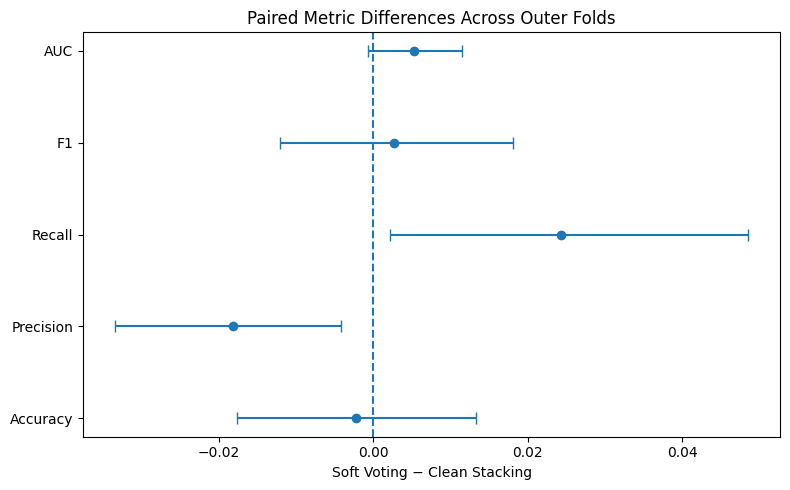

In [38]:
# Report Figure: proposed model minus clean stacking
plot_ci = paired_ci.copy()

y = np.arange(len(plot_ci))

lower_error = (
    plot_ci["Mean Difference"]
    - plot_ci["Descriptive 95% Bootstrap Lower"]
)

upper_error = (
    plot_ci["Descriptive 95% Bootstrap Upper"]
    - plot_ci["Mean Difference"]
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    plot_ci["Mean Difference"],
    y,
    xerr=[lower_error, upper_error],
    fmt="o",
    capsize=4
)

ax.axvline(0, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(plot_ci["Metric"])
ax.set_xlabel("Soft Voting − Clean Stacking")
ax.set_title("Paired Metric Differences Across Outer Folds")

plt.tight_layout()
plt.show()

## 31. Accuracy distribution across outer test folds

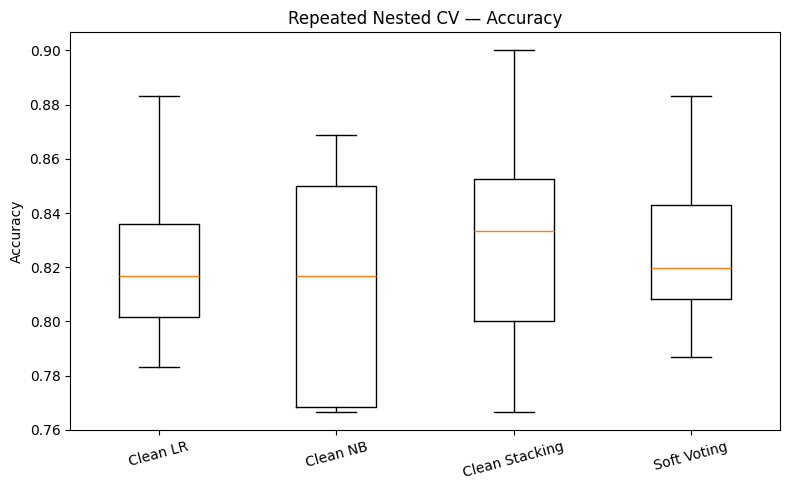

In [39]:
accuracy_groups = [
    nested_results.loc[
        nested_results["Model"] == model_name,
        "Accuracy"
    ].to_numpy()
    for model_name in [
        "Clean LR",
        "Clean NB",
        "Clean Stacking",
        "Proposed Soft Voting"
    ]
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    accuracy_groups,
    labels=[
        "Clean LR",
        "Clean NB",
        "Clean Stacking",
        "Soft Voting"
    ]
)
ax.set_ylabel("Accuracy")
ax.set_title("Repeated Nested CV — Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 32. AUC distribution across outer test folds

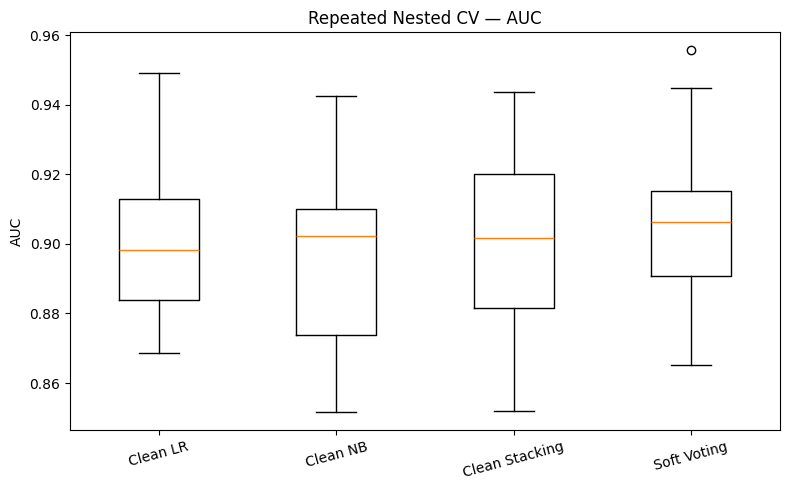

In [40]:
auc_groups = [
    nested_results.loc[
        nested_results["Model"] == model_name,
        "AUC"
    ].to_numpy()
    for model_name in [
        "Clean LR",
        "Clean NB",
        "Clean Stacking",
        "Proposed Soft Voting"
    ]
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    auc_groups,
    labels=[
        "Clean LR",
        "Clean NB",
        "Clean Stacking",
        "Soft Voting"
    ]
)
ax.set_ylabel("AUC")
ax.set_title("Repeated Nested CV — AUC")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 33 Save robustness results

In [41]:
nested_results.to_csv(
    "results_part2_nested_cv_folds.csv",
    index=False
)

nested_summary.to_csv(
    "results_part2_nested_cv_summary.csv",
    index=False
)

paired_comparison.to_csv(
    "results_part2_nested_cv_paired.csv",
    index=False
)

paired_ci.to_csv(
    "results_part2_nested_cv_paired_ci.csv",
    index=False
)

best_params_nested.to_csv(
    "results_part2_nested_cv_best_params.csv",
    index=False
)

print("Saved robustness-validation tables.")

Saved robustness-validation tables.
